Problem: https://judge.nitro-ai.org/competitions/roai-2025/lot-baraj-2/2/view

In [2]:
import os
import zipfile
import shutil
import pandas as pd
import seaborn as sns

train_df = pd.read_csv('train_data.csv')
train_df

,IDSample,FrameNumber,J1X,J1Y,J1Z,J2X,J2Y,J2Z,J3X,J3Y,...,J23Y,J23Z,J24X,J24Y,J24Z,J25X,J25Y,J25Z,Action,Camera
0,1,1,0.164490,0.291355,3.091319,0.189296,0.615010,3.080443,0.209298,0.928650,...,0.249604,2.929706,0.237679,0.185178,2.881282,0.290780,0.236038,2.852048,3,1
1,1,2,0.164051,0.291135,3.091265,0.187257,0.614560,3.080929,0.206220,0.927991,...,0.242949,2.934857,0.237713,0.184868,2.881657,0.288819,0.236270,2.851250,3,1
2,1,3,0.160394,0.291922,3.091712,0.183053,0.614688,3.081785,0.202935,0.927368,...,0.261962,2.940350,0.237603,0.182165,2.880324,0.286495,0.221468,2.868750,3,1
3,1,4,0.157784,0.291979,3.090791,0.179416,0.614119,3.081133,0.198786,0.925982,...,0.257649,2.934111,0.231934,0.184934,2.879659,0.289556,0.229324,2.863987,3,1
4,1,5,0.154023,0.289773,3.091381,0.174946,0.611712,3.081385,0.194107,0.923457,...,0.252397,2.932880,0.223781,0.178191,2.879539,0.278711,0.216850,2.864786,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313757,3354,66,0.124463,0.045098,3.897985,0.131224,0.283489,3.804036,0.137337,0.516286,...,0.380826,4.139340,0.089510,-0.146611,3.782170,0.129325,-0.109713,3.752250,0,2
313758,3354,67,0.124353,0.046044,3.897914,0.131206,0.284605,3.804398,0.137483,0.518154,...,0.383014,4.140001,0.095534,-0.105978,3.747674,0.113525,-0.086582,3.721333,0,2
313759,3354,68,0.124022,0.046228,3.899844,0.131326,0.284203,3.805034,0.138024,0.517198,...,0.382078,4.139925,0.075997,-0.105313,3.754425,0.159437,-0.052298,3.777667,0,2
313760,3354,69,0.130853,0.045207,3.903951,0.133637,0.284368,3.806365,0.138381,0.517753,...,0.382587,4.139922,0.088620,-0.106126,3.755745,0.100540,-0.103106,3.730200,0,2


In [3]:
print(train_df['Action'].unique())
print(train_df['Camera'].unique())

[3 0 1 4 2]
[1 2 3]


<Axes: ylabel='Count'>

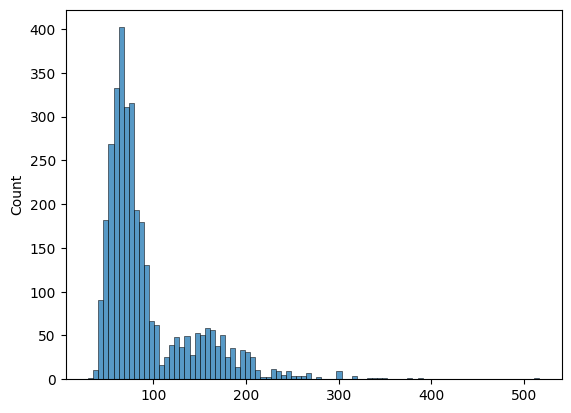

In [4]:
lens = [len(df) for id, df in train_df.groupby('IDSample')]
sns.histplot(lens)

In [6]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

ids =  [id for id, _ in train_df.groupby('IDSample')]
train_ids, val_ids = train_test_split(ids, test_size=0.1)

class PositionSequencesDataset(Dataset):
    def __init__(self, df, ids):
        self.samples = []
        for sid in ids:
            group = df[df['IDSample'] == sid]
            x = torch.tensor(group.drop(['Action', 'Camera', 'IDSample', 'FrameNumber'], axis=1).values, dtype=torch.float32)
            y_a = torch.tensor(group['Action'].iloc[0], dtype=torch.long)
            y_c = torch.tensor(group['Camera'].iloc[0] - 1, dtype=torch.long)
            self.samples.append((x, y_a, y_c))

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        return self.samples[index]
    
def collate_fn(batch):
    x, y_a, y_c = zip(*batch)
    lens = torch.tensor([len(one_x) for one_x in x])
    x_pad = pad_sequence(x, batch_first=True)
    return x_pad, torch.stack(y_a), torch.stack(y_c), lens

train_ds = PositionSequencesDataset(train_df, train_ids)
val_ds   = PositionSequencesDataset(train_df, val_ids)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)

In [10]:
from torch import nn
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=75, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
        )
        self.head_action = nn.Linear(hidden_size * 2, 5)
        self.head_camera = nn.Linear(hidden_size * 2, 3)

    def forward(self, x, lens):
        x = pack_padded_sequence(x, lens.cpu(), batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(x)
        pooled = torch.cat((h[-2], h[-1]), dim=1)

        return self.head_action(pooled), self.head_camera(pooled)

In [14]:
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
def run_epoch(model, criterion, optimizer, device, loader, scheduler = None, train=True):
    model.train() if train else model.eval()
    total_loss, correct_a, correct_c, n = 0.0, 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y_a, y_c, lens in loader:
            x, y_a, y_c = x.to(device), y_a.to(device), y_c.to(device)

            logits_a, logits_c = model(x, lens)               # (B, T, 5)
            # reshape for CrossEntropyLoss: (B*T, 5) vs (B*T,)
            loss_a = criterion(logits_a, y_a)
            loss_c = criterion(logits_c, y_c)
            loss = loss_a + loss_c

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item() * x.size(0)
            correct_a  += (torch.argmax(logits_a, dim=1) == y_a).sum().item()
            correct_c  += (torch.argmax(logits_c, dim=1) == y_c).sum().item()
            n          += x.size(0)

    return total_loss / n, correct_a / n, correct_c / n

In [ ]:
device = 'cuda'
train_losses_per_sheduler, val_losses_per_sheduler = [], []

EPOCHS = 20

for i in range(0,3):
    model = LSTMClassifier()
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    scheduler = {
        0: None,
        1: CosineAnnealingLR(optimizer, T_max=EPOCHS),
        2: ReduceLROnPlateau(optimizer, patience=5)
    }[i]
    train_losses_per_sheduler.append([])
    val_losses_per_sheduler.append([])

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc_a, tr_acc_c = run_epoch(model, criterion, optimizer, device, train_loader, scheduler, train=True)
        vl_loss, vl_acc_a, vl_acc_c = run_epoch(model, criterion, optimizer, device, val_loader, scheduler, train=False)
        train_losses_per_sheduler[i].append(tr_loss)
        val_losses_per_sheduler[i].append(vl_loss)
        print(f"Epoch {epoch:02d} | "
            f"train loss {tr_loss:.4f} action acc {tr_acc_a:.3f} camera acc {tr_acc_c:.3f} | "
            f"val loss {vl_loss:.4f} a action acc {vl_acc_a:.3f} camera acc {vl_acc_c:.3f}")

Epoch 01 | train loss 2.3053 action acc 0.405 camera acc 0.415 | val loss 2.1448 a action acc 0.515 camera acc 0.435
Epoch 02 | train loss 1.9686 action acc 0.544 camera acc 0.461 | val loss 1.9021 a action acc 0.640 camera acc 0.476
Epoch 03 | train loss 1.8066 action acc 0.607 camera acc 0.467 | val loss 1.8020 a action acc 0.589 camera acc 0.485
Epoch 04 | train loss 1.7583 action acc 0.646 camera acc 0.471 | val loss 1.6013 a action acc 0.723 camera acc 0.458
Epoch 05 | train loss 1.6758 action acc 0.680 camera acc 0.502 | val loss 1.5425 a action acc 0.747 camera acc 0.485
Epoch 06 | train loss 1.5701 action acc 0.719 camera acc 0.501 | val loss 1.4873 a action acc 0.759 camera acc 0.518
Epoch 07 | train loss 1.5725 action acc 0.709 camera acc 0.506 | val loss 1.4939 a action acc 0.774 camera acc 0.500
Epoch 08 | train loss 1.4835 action acc 0.734 camera acc 0.517 | val loss 1.4845 a action acc 0.765 camera acc 0.512
Epoch 09 | train loss 1.4647 action acc 0.724 camera acc 0.529 |

TypeError: ReduceLROnPlateau.step() missing 1 required positional argument: 'metrics'

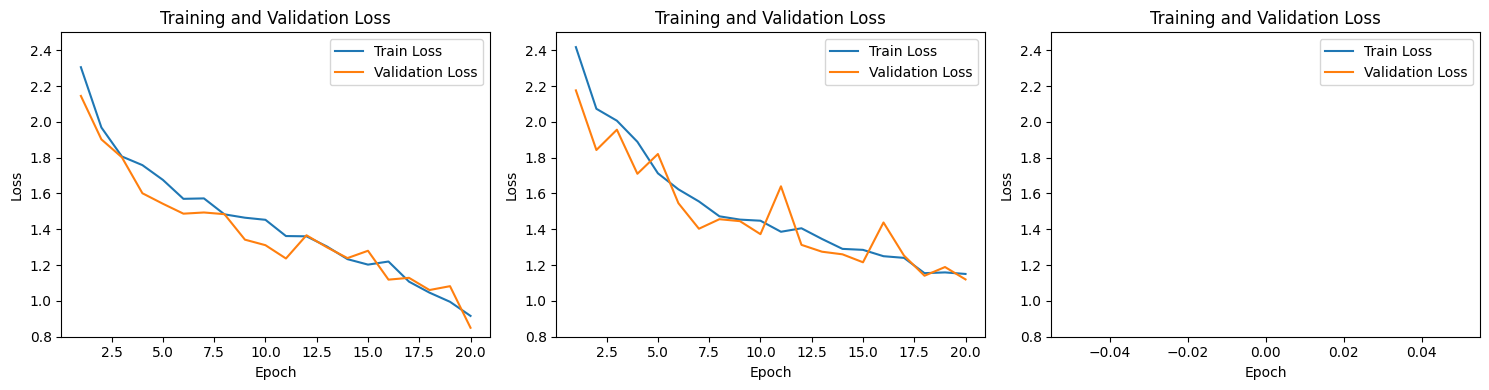

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, (train_losses, val_losses) in enumerate(zip(train_losses_per_sheduler, val_losses_per_sheduler)):
    epochs = range(1, len(train_losses) + 1)

    ax[i].plot(epochs, train_losses, label="Train Loss")
    ax[i].plot(epochs, val_losses, label="Validation Loss")

    ax[i].set_ylim(0.8, 2.5)

    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")
    ax[i].set_title("Training and Validation Loss")
    ax[i].legend()

plt.tight_layout()
plt.show()
#0.965 / 0.8